In [46]:
import pandas as pd
from datetime import date
from pathlib import Path
import matplotlib.pyplot as plt

In [47]:
START_DATE = date(2018, 1, 1)
END_DATE = date(2022, 12, 31)

COVARIATE = "heat_index" # temp or heat_index

PLOT_OUTPUT_FILE = Path(f"../plots/mses/mses_{COVARIATE}_{START_DATE}_{END_DATE}.png")
PLOT_DATA_FILE = Path(f"../data/{COVARIATE}/mses_{COVARIATE}_{START_DATE}_{END_DATE}_data.csv")

assert PLOT_DATA_FILE.exists(), f"{PLOT_DATA_FILE} file doesn't exist"

In [48]:
df = pd.read_csv(PLOT_DATA_FILE, index_col = 0)
minrow = df.loc[df.mse.idxmin()]
f"lowest split/formula: {minrow.split}/{minrow.formula}"

'lowest split/formula: 0.7/Model 5'

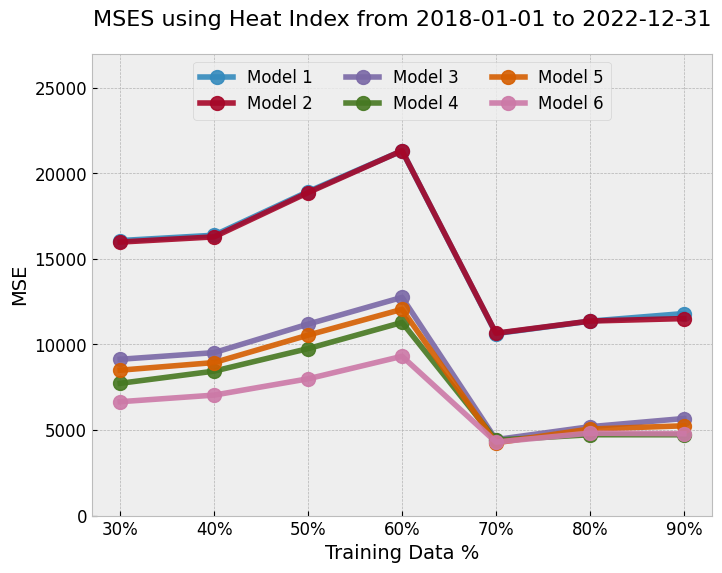

In [49]:
plt.style.use('bmh')
covariate_for_title = "Temperature" if COVARIATE == "temp" else "Heat Index"

plt.figure(figsize = (8, 6))

for formula in range(1, 7):
    df_formula = df[df.formula == f"Model {formula}"]
    plt.plot(df_formula.split, df_formula.mse, "-o", label = f"Model {formula}", alpha = 0.9, lw = 4, markersize = 10)
    # plt.scatter(df_formula.split, df_formula.mse, alpha = 0.9, s = 3)

plt.ylabel("MSE", fontsize = 14)
plt.xlabel("Training Data %", fontsize = 14)
plt.xticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], ["30%", "40%", "50%", "60%", "70%", "80%", "90%"])
plt.tick_params(axis='both', labelsize=12)
plt.title(f"MSES using {covariate_for_title} from {START_DATE} to {END_DATE}", fontsize = 16, pad = 20)
plt.legend(loc="upper center", ncols = 3, fontsize = 12)
plt.ylim(0, 27000)

plt.savefig(PLOT_OUTPUT_FILE, dpi = 300)